# Iris Species Classification

**Objective**: To classify Iris flower species based on sepal and petal measurements using the K-Nearest Neighbors (KNN) classification algorithm.

## 1. Import Libraries


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## 2. Load Dataset

In [59]:

df= pd.read_csv("/iris.csv")
df.head()



,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Data Exploration

In [60]:
df.info()
df.shape
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


np.int64(3)

## 4. Data Cleaning

In [61]:
df.drop_duplicates(inplace=True)

In [62]:
df.shape


(147, 5)

**Observation:** Three duplicate records were identified and removed from the dataset. The cleaned dataset contains 147 records.

## 6. Data Preprocessing

In [63]:

le=LabelEncoder()
df["species"]=le.fit_transform(df["species"])
print(df)

     sepal_length  sepal_width  petal_length  petal_width  species
0             5.1          3.5           1.4          0.2        0
1             4.9          3.0           1.4          0.2        0
2             4.7          3.2           1.3          0.2        0
3             4.6          3.1           1.5          0.2        0
4             5.0          3.6           1.4          0.2        0
..            ...          ...           ...          ...      ...
145           6.7          3.0           5.2          2.3        2
146           6.3          2.5           5.0          1.9        2
147           6.5          3.0           5.2          2.0        2
148           6.2          3.4           5.4          2.3        2
149           5.9          3.0           5.1          1.8        2

[147 rows x 5 columns]


In [64]:
X = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]

y = df["species"]
print(X)
print(y)


     sepal_length  sepal_width  petal_length  petal_width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[147 rows x 4 columns]
0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: species, Length: 147, dtype: int64


## 5. Exploratory Data Analysis

### 5.1 Species Distribution

In [65]:
df["species"].value_counts()

,count
species,
1,50
2,49
0,48


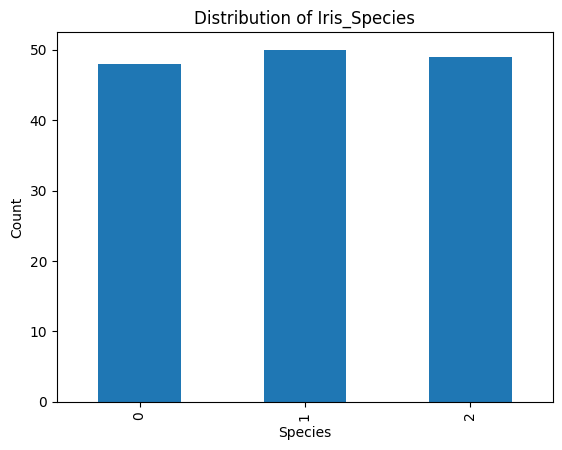

In [66]:
df["species"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Iris_Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

**Observation**: The three species classes are nearly equally represented, indicating that the dataset is well balanced.

### 5.2 Petal Length vs Petal Width

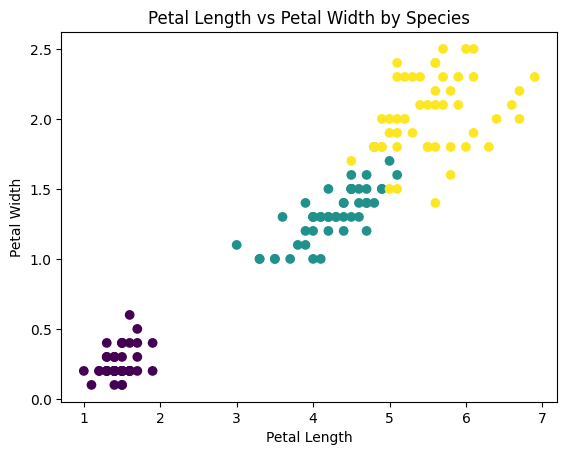

In [67]:

plt.scatter(
    df["petal_length"],
    df["petal_width"],
    c=df["species"]
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Petal Length vs Petal Width by Species")
plt.show()

### 5.3 Correlation Analysis

In [68]:
correlation = df[
    ["sepal_length", "sepal_width", "petal_length", "petal_width"]
].corr()

print(correlation)

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.109321      0.871305     0.817058
sepal_width      -0.109321     1.000000     -0.421057    -0.356376
petal_length      0.871305    -0.421057      1.000000     0.961883
petal_width       0.817058    -0.356376      0.961883     1.000000


**Observation**: Petal length and petal width have the strongest positive correlation (0.962), indicating that flowers with longer petals generally tend to have wider petals.

## 7. Train-Test Split

In [69]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train)
print(X_test)
print(y_train)
print(y_test)


     sepal_length  sepal_width  petal_length  petal_width
137           6.4          3.1           5.5          1.8
47            4.6          3.2           1.4          0.2
121           5.6          2.8           4.9          2.0
27            5.2          3.5           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
73            6.1          2.8           4.7          1.2
108           6.7          2.5           5.8          1.8
14            5.8          4.0           1.2          0.2
94            5.6          2.7           4.2          1.3
104           6.5          3.0           5.8          2.2

[117 rows x 4 columns]
     sepal_length  sepal_width  petal_length  petal_width
127           6.1          3.0           4.9          1.8
53            5.5          2.3           4.0          1.3
140           6.7          3.1           5.6          2.4
19            5.1          3.8           1.5    

## 8. Feature Scaling

In [70]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_train)
print(X_test)

[[ 0.59486878  0.05831127  0.94250316  0.76726863]
 [-1.60687754  0.28572521 -1.38920785 -1.36694663]
 [-0.38368514 -0.62393057  0.60127716  1.03404553]
 [-0.8729621   0.96796705 -1.33233685 -1.36694663]
 [-1.11760058  1.195381   -1.38920785 -1.36694663]
 [ 1.57342271 -0.16910268  1.11311616  0.50049172]
 [ 2.42965739  1.65020889  1.45434216  1.03404553]
 [ 0.3502303   0.74055311  0.88563216  1.43421089]
 [-0.99528134  1.65020889 -1.10485285 -1.10016972]
 [-0.62832362  1.87762284 -1.44607885 -1.10016972]
 [-0.62832362  1.42279495 -1.33233685 -1.36694663]
 [ 2.18501891  1.65020889  1.62495516  1.30082244]
 [ 0.47254954 -1.7610003   0.31692216  0.10032636]
 [ 1.20646499  0.05831127  0.71501916  1.43421089]
 [ 0.83950727 -0.39651662  0.43066416  0.10032636]
 [-0.2613659  -0.16910268  0.20318015 -0.0330621 ]
 [ 1.08414575  0.28572521  1.16998716  1.43421089]
 [ 0.71718803  0.28572521  0.71501916  1.03404553]
 [-0.99528134  0.96796705 -1.38920785 -1.36694663]
 [ 0.83950727 -0.16910268  0.31

## 9. KNN Model Training

In [71]:

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=3)

## 10. Prediction

In [72]:
y_pred = model.predict(X_test)
print(y_pred)

[2 1 2 0 1 0 1 0 2 0 0 1 2 1 2 1 0 1 2 0 0 2 0 2 1 0 1 2 1 0]


## 11. Model Evaluation

In [73]:

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.9333333333333333
Precision: 0.9333333333333333
Recall: 0.9333333333333333
F1 Score: 0.9333333333333333
Confusion Matrix:
 [[11  0  0]
 [ 0  9  1]
 [ 0  1  8]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.90      0.90      0.90        10
           2       0.89      0.89      0.89         9

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

